Momentum Final weight: 2.0046863555908203
RMSprop Final weight: 1.0355110168457031
Adam Final weight: 0.9015510678291321


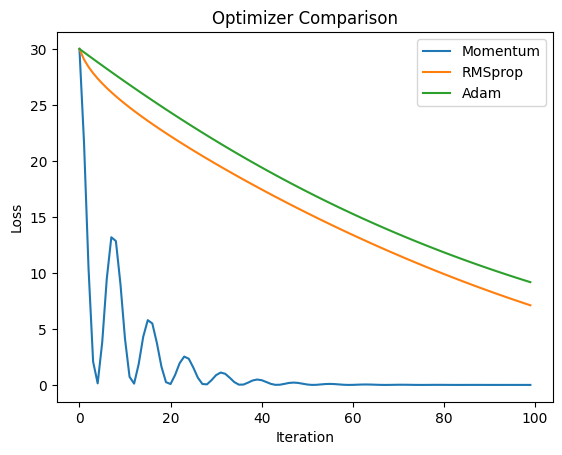

In [1]:
import torch
import matplotlib.pyplot as plt

x = torch.tensor([[1.0], [2.0], [3.0], [4.0]])
y = torch.tensor([[2.0], [4.0], [6.0], [8.0]])

def train(optimizer_name):

    w = torch.tensor([[0.0]], requires_grad=True)

    velocity = torch.zeros_like(w)
    s = torch.zeros_like(w)
    m = torch.zeros_like(w)

    losses = []

    for t in range(1, 101):

        pred = x @ w
        loss = torch.mean((pred-y)**2)

        loss.backward()

        g = w.grad

        if optimizer_name == "Momentum":
            velocity = 0.9 * velocity - 0.01 * g
            w.data += velocity

        elif optimizer_name == "RMSprop":
            s = 0.9*s + 0.1*g*g
            w.data -= 0.01*g/(torch.sqrt(s)+1e-8)

        elif optimizer_name == "Adam":
            m = 0.9*m + 0.1*g
            s = 0.999*s + 0.001*g*g

            m_hat = m/(1-0.9**t)
            s_hat = s/(1-0.999**t)

            w.data -= 0.01*m_hat/(torch.sqrt(s_hat)+1e-8)

        w.grad.zero_()

        losses.append(loss.item())

    return losses, w.item()


for name in ["Momentum", "RMSprop", "Adam"]:

    losses, weight = train(name)

    plt.plot(losses, label=name)

    print(name, "Final weight:", weight)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Optimizer Comparison")
plt.legend()
plt.show()